In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
# 1. LOAD DATA
df = pd.read_csv("sales_data.csv")

In [ ]:
# 2. FEATURE ENGINEERING (SAMA SEPERTI SEBELUMNYA)

# A. Encode Data Kategorikal (Ubah Teks ke Angka)
le = LabelEncoder()
cols_to_encode = ['product_category_name', 'seller_state', 'seller_city']
for col in cols_to_encode:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# B. Buat Fitur Baru: "Price Segment" (KUNCI AKURASI)
# Mengubah avg_order_value (angka) menjadi Kategori (0=Murah, 1=Sedang, 2=Mahal)
# Kita pakai qcut untuk membagi data menjadi 3 kelompok sama besar
df['price_segment'] = pd.qcut(df['avg_order_value'], q=3, labels=[0, 1, 2]).astype(int)

# TARGET: High vs Low Performance
# Tetap pakai Median Sales sebagai batas (agar seimbang 50:50)
threshold = df['total_sales'].median()
df['performance_tier'] = (df['total_sales'] > threshold).astype(int)

In [ ]:
# 3. PILIH FITUR
# Kombinasi: Volume (Orders) + Value (Price Segment) + Profil (Lokasi/Kategori)
features_final = [
    'total_orders',           # Seberapa sering laku
    'price_segment',          # Seberapa mahal barangnya
    'product_category_name',  # Apa yang dijual
    'seller_state',           # Provinsi
    'seller_city'             # Kota
]

X = df[features_final]
y = df['performance_tier']

In [ ]:
# 4. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training dengan 36586 data...


In [ ]:
# 5. TRAINING MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# 6. EVALUASI
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("-" * 40)
print("=== FINAL RESULT: RANDOM FOREST ===")
print(f"Akurasi Model pada Data Ujian: {accuracy * 100:.2f}%")
print("-" * 40)
print(classification_report(y_test, y_pred))

print("-" * 40)
print("Faktor Penentu (Feature Importance):")
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

----------------------------------------
=== FINAL RESULT: RANDOM FOREST ===
Akurasi Model pada Data Ujian: 92.54%
----------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      4589
           1       0.92      0.93      0.93      4558

    accuracy                           0.93      9147
   macro avg       0.93      0.93      0.93      9147
weighted avg       0.93      0.93      0.93      9147

----------------------------------------
Faktor Penentu (Feature Importance):
price_segment            0.490397
total_orders             0.368575
seller_city              0.071307
product_category_name    0.056581
seller_state             0.013141
dtype: float64


----------------------------------------
ROC-AUC Score: 0.9665
----------------------------------------
Confusion Matrix:
[[4206  383]
 [ 299 4259]]


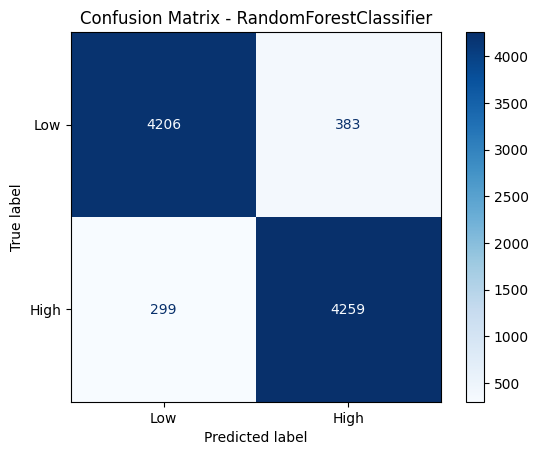

In [ ]:
# Hitung Confusion Matrix, btw gw copy paste ini smw ke 5 modelny, mager
cm = confusion_matrix(y_test, y_pred)

# Hitung ROC-AUC
# Cek apakah model punya method predict_proba (DT, RF, GBT, LR punya)
# SVM LinearSVC g punya predict_proba default, jadi pakai decision_function atau y_pred biasa
try:
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_score = roc_auc_score(y_test, y_prob)
except AttributeError:
    # Fallback untuk SVM LinearSVC atau jika error
    try:
        y_prob = model.decision_function(X_test)
        roc_score = roc_auc_score(y_test, y_prob)
    except:
        roc_score = roc_auc_score(y_test, y_pred)

print("-" * 40)
print(f"ROC-AUC Score: {roc_score:.4f}")
print("-" * 40)
print("Confusion Matrix:")
print(cm)

# 3. Tampilkan Plot Confusion Matrix
# 0 = Low Performance, 1 = High Performance
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {model.__class__.__name__}")
plt.show()

# Kotak Kiri Atas & Kanan Bawah (Biru Gelap): Jawaban Benar. Makin gelap makin bagus.
# Kotak Kanan Atas (False Positive): Model bilang "Sukses", aslinya "Gagal".
# Kotak Kiri Bawah (False Negative): Model bilang "Gagal", aslinya "Sukses".